# Plotting stats on Gasterosteus sex chromosomes

### Import some modules

In [47]:
import numpy as np
from matplotlib import pyplot as plt
from scipy.optimize import curve_fit

### Some quality of life settings

Align tables

In [2]:
%%html
<style>
table {align:left; display:block}
</style>

Global maplotlib font settings

### dS outlier removal function

In [3]:
def remove_outlier_dS(dS_list, zscore_threshold):

    import numpy as np
    from scipy import stats
    from matplotlib import pyplot as plt

    dS_arr = np.array(dS_list)

    # Calculate z-scores
    dS_zscores = stats.zscore(dS_arr)

    # Set threshold for identifying outliers
    threshold = zscore_threshold  # Lower = more lenient

    # Find outliers

    outlier_mask = np.abs(dS_zscores) > threshold
    outliers_indices = np.where(np.abs(dS_zscores) > threshold)[0]  # Indices of outliers
    outlier_values = dS_arr[outliers_indices]  # Corresponding values

    # Get the original array excluding outliers
    dS_sans_outliers = dS_arr[~outlier_mask]  # Values that are not outliers

    print("%s Outlier values: %s" % (len(outlier_values), outlier_values))
    
    print("mean before outlier removal=", np.round(np.mean(dS_arr),2))
    print("mean after outlier removal=", np.round(np.mean(dS_sans_outliers),2))
    
    plt.figure(figsize = (10,5))
    plt.violinplot(dS_arr, positions=[1],  showmeans = True)
    plt.scatter([1]*len(dS_arr),dS_arr)
    plt.scatter([1]*len(outlier_values), outlier_values, color = "red")
    
    plt.violinplot(dS_sans_outliers, positions=[2], showmeans = True)
    plt.scatter([2]*len(dS_sans_outliers),dS_sans_outliers)
    
    plt.show()
    
    return dS_sans_outliers

## Strata locations for each species 

In [4]:
Ga_strata = {}
Ga_strata["S1"]  = (12500000, 21000000)
Ga_strata["S2"]  = (2500000, 6900000)
Ga_strata["S3"]  = (6900000, 12500000)
Ga_strata["PAR"] = (0, 2500000)

In [5]:
Gw_strata = {}
Gw_strata["chr19"] = {}
Gw_strata["chr19"] ["S19_1"]  = (0, 14850000)
Gw_strata["chr19"] ["S19_2"]  = (14850000, 23300000)

Gw_strata["chr12"] = {}
Gw_strata["chr12"]["S12_1"]  = (21480000, 24620000)
Gw_strata["chr12"]["S12_2.1"]  = (17210000, 21480000)
Gw_strata["chr12"]["S12_2_Rec"]  = (15290000, 17210000)
Gw_strata["chr12"]["S12_2.2"]  = (11740000, 15290000)
Gw_strata["chr12"]["S12_3"]  = (6300000, 11740000)
Gw_strata["chr12"]["PAR"] = (0,6300000)

## Plotting Gene loss vs Stratum age

We have characterised genes as being retained or lost from the Y based on orthology (or lack thereof) and read depth for raw sequence alignments. We can then plot the number of genes lost per stratum. However this is most useful if we compare it to dS, which gives some proxy for the age of the stratum. 

### Threespine

#### Work

In [6]:
Ga_dS_path = "/Users/dj20y461/Data_temp/Stickleback/Stickle_Y_comp/results_2025/04.dnds/Ga/dNdS.result"

In [7]:
with open(Ga_dS_path) as Ga_dS:
    
    Ga_ds_dict = {}    
    header = next(Ga_dS)
    for line in Ga_dS:
        if line.split()[9] != "NA":
            Ga_ds_dict[int(line.split()[2])] = float(line.split()[9])

Get the dS values for genes within each of the strata. 

In [8]:
Ga_dS_per_strata_dict = {}

Ga_dS_per_strata_dict["S1"] = {}
Ga_dS_per_strata_dict["S1"]["dS"] = []
Ga_dS_per_strata_dict["S2"] = {}
Ga_dS_per_strata_dict["S2"]["dS"] = []
Ga_dS_per_strata_dict["S3"] = {}
Ga_dS_per_strata_dict["S3"]["dS"] = []

for locus in Ga_ds_dict:
        
    if Ga_strata["S1"][0] < locus <= Ga_strata["S1"][1]:
        Ga_dS_per_strata_dict["S1"]["dS"].append(Ga_ds_dict[locus])
    elif Ga_strata["S2"][0] < locus <= Ga_strata["S2"][1]:
        Ga_dS_per_strata_dict["S2"]["dS"].append(Ga_ds_dict[locus])
    elif Ga_strata["S3"][0] < locus <= Ga_strata["S3"][1]:
        Ga_dS_per_strata_dict["S3"]["dS"].append(Ga_ds_dict[locus])
        


Now remove outliers 

S1
6 Outlier values: [0.335765 0.421311 0.78874  0.583068 0.486325 0.871597]
mean before outlier removal= 0.17
mean after outlier removal= 0.12


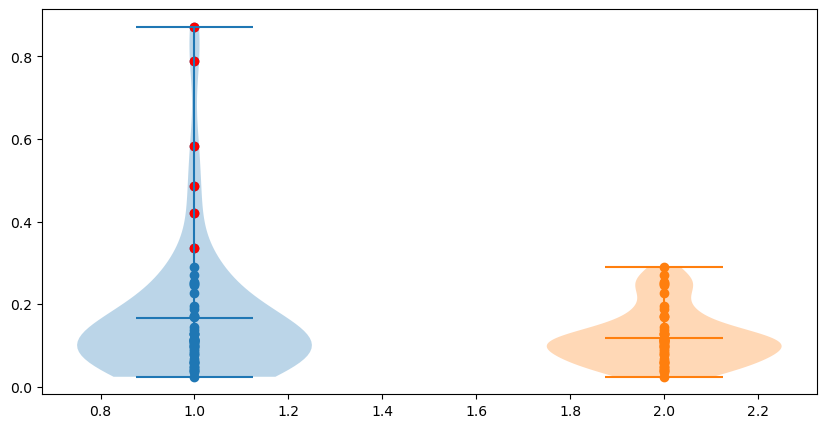

S2
8 Outlier values: [0.163639 0.18083  0.426266 0.151779 0.140771 0.147704 0.14512  0.157413]
mean before outlier removal= 0.06
mean after outlier removal= 0.05


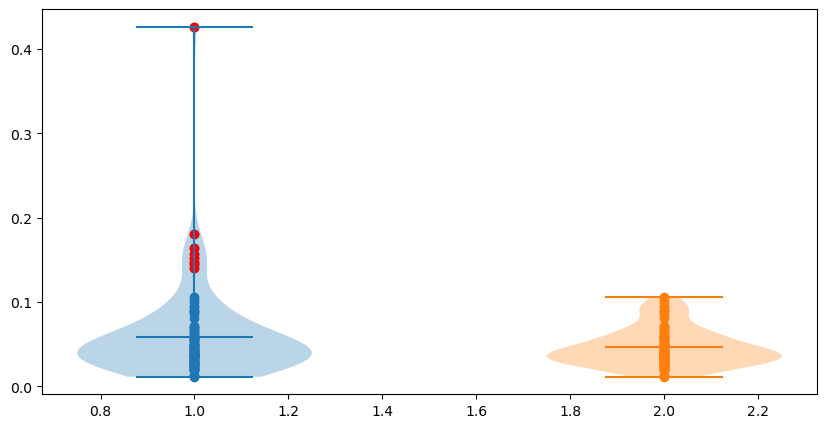

S3
7 Outlier values: [0.194046 0.437485 0.186181 0.29878  1.37256  0.376381 0.579074]
mean before outlier removal= 0.06
mean after outlier removal= 0.04


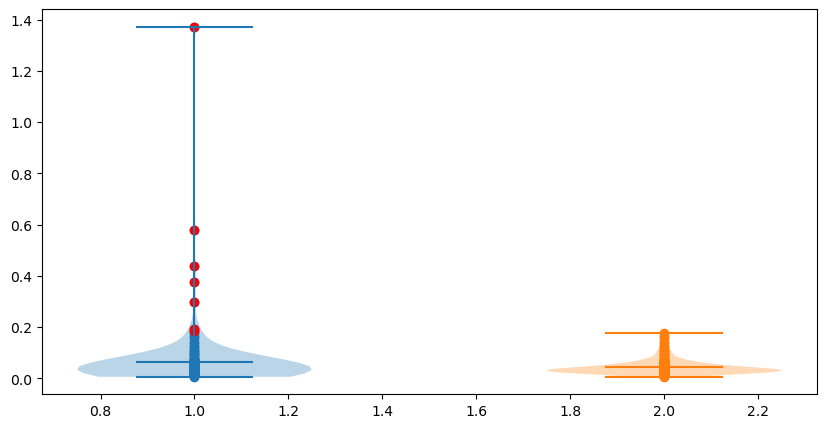

In [9]:
for stratum in Ga_dS_per_strata_dict:
    print(stratum)
    Ga_dS_per_strata_dict[stratum]["dS_remv_outliers"] = remove_outlier_dS(Ga_dS_per_strata_dict[stratum]["dS"], 1)

Now get the number of genes that have been lost in each stratum

First, I need to know how many genes are in the stratum in total. I'll do this from the gff

In [10]:
### Get all gene positions 

Ga_gff_path = "/Users/dj20y461/Downloads/Ga.longest.gff3"
chr19_refseqID="NC_053230.1"

Ga_gene_dict = {}
Ga_chr19_gene_dict = {}

with open(Ga_gff_path) as Ga_gff:

    for line in Ga_gff:
        
        if not line.startswith("#"):
        
            if line.split()[2] == "mRNA":
                info_line = line.split()[8]

                for field in info_line.split(";"):
                    if field.startswith("ID"):
                        gene_name = field.split("=")[1]
                        gene_start = line.split()[3]
                        gene_end = line.split()[4]
                        gene_chrom = line.split()[0]

                Ga_gene_dict[gene_name] = {}
                Ga_gene_dict[gene_name]["start"] = int(gene_start)
                Ga_gene_dict[gene_name]["end"] = int(gene_end)
                Ga_gene_dict[gene_name]["chrom"] = gene_chrom
                
                if line.split()[0] == chr19_refseqID:

                    Ga_chr19_gene_dict[gene_name] = {}
                    Ga_chr19_gene_dict[gene_name]["start"] = int(gene_start)
                    Ga_chr19_gene_dict[gene_name]["end"] = int(gene_end)


In [11]:
len(Ga_gene_dict)

22114

In [12]:
## bin genes into their strata

Genes_per_stratum = {}

for stratum in Ga_strata:
    Genes_per_stratum[stratum] = []

for gene in Ga_chr19_gene_dict:
    
    for stratum in Ga_strata:
    
        if Ga_strata[stratum][0] < Ga_chr19_gene_dict[gene]["start"] <= Ga_strata[stratum][1]:
            Genes_per_stratum[stratum].append(gene)
    
    

In [13]:
total_gene_count = 0
for stratum in Genes_per_stratum:
    print(stratum, len(Genes_per_stratum[stratum]))
    total_gene_count += len(Genes_per_stratum[stratum])
    
print(total_gene_count)

S1 487
S2 203
S3 269
PAR 159
1118


Now find which genes have been lost.

In [14]:
Ga_gene_groups_path = "/Users/dj20y461/Data_temp/Stickleback/Stickle_Y_comp/results_2025/99.misc/Gene.groups/Ga.gene.groups"

Ga_gene_status = {}

with open(Ga_gene_groups_path) as Ga_gene_groups:
    
    header = next(Ga_gene_groups)
    
    for line in Ga_gene_groups:

        line = line.strip()
        
        gene_name = line.split()[0]
        
        Ga_gene_status[gene_name] = {}
        Ga_gene_status[gene_name]["status"] = line.split("\t")[2]



In [15]:
len(Ga_gene_status)

972

In [16]:
for gene in Ga_gene_status:
    
    if gene in Ga_chr19_gene_dict:
        
        Ga_gene_status[gene]["start"] = Ga_chr19_gene_dict[gene]["start"]
    

finally add the stratas

In [17]:
for gene in Ga_gene_status:
    
    for stratum in Ga_strata:
        if Ga_strata[stratum][0] < Ga_gene_status[gene]["start"] <= Ga_strata[stratum][1]: 
            Ga_gene_status[gene]["stratum"] = stratum

Now plot the data

In [18]:
## Plotting all 1n genes first

Ga_x = {}
strata = ["S1", "S2", "S3"]

for stratum in strata:
    Ga_x[stratum] = {}
    Ga_x[stratum]["mean"] = np.mean(Ga_dS_per_strata_dict[stratum]["dS_remv_outliers"])
    Ga_x[stratum]["std"] = np.std(Ga_dS_per_strata_dict[stratum]["dS_remv_outliers"])
    
Ga_y = {} 

for stratum in strata:
    
    count_1n = 0
    count_stratum_total = 0
    for gene in Ga_gene_status:
        if Ga_gene_status[gene]["stratum"] == stratum:
            count_stratum_total += 1
            if Ga_gene_status[gene]["status"] == "1n":
                count_1n += 1
    print(stratum, count_1n, count_stratum_total, len(Genes_per_stratum[stratum]))
    Ga_y[stratum] = count_1n/count_stratum_total


S1 401 456 487
S2 70 163 203
S3 70 236 269


In [19]:
## Plotting all 1n and 1n-2n genes first

Ga_x_all_lost = {}
strata = ["S1", "S2", "S3"]

for stratum in strata:
    Ga_x_all_lost[stratum] = {}
    Ga_x_all_lost[stratum]["mean"] = np.mean(Ga_dS_per_strata_dict[stratum]["dS_remv_outliers"])
    Ga_x_all_lost[stratum]["std"] = np.std(Ga_dS_per_strata_dict[stratum]["dS_remv_outliers"])
    
Ga_y_all_lost = {} 

for stratum in strata:
    
    count_1n = 0
    count_stratum_total = 0
    for gene in Ga_gene_status:
        if Ga_gene_status[gene]["stratum"] == stratum:
            count_stratum_total += 1
            if Ga_gene_status[gene]["status"] in ["1n", "1n-2n"]:
                count_1n += 1
    print(stratum, count_1n, count_stratum_total, len(Genes_per_stratum[stratum]))
    Ga_y_all_lost[stratum] = count_1n/count_stratum_total


S1 433 456 487
S2 128 163 203
S3 156 236 269


### Blackspotted

#### Work

In [20]:
Gw_dS_path = "/Users/dj20y461/Data_temp/Stickleback/Stickle_Y_comp/results_2025/04.dnds/Gw/dNdS.result"

In [21]:
with open(Gw_dS_path) as Gw_dS:
    
    Gw_ds_dict = {}   
    Gw_ds_dict["chr19"] = {}
    Gw_ds_dict["chr12"] = {}
    
    header = next(Gw_dS)
    
    for line in Gw_dS:
        
        if line.split()[9] != "NA":
        
            chrom = line.split()[1]
            gene_start = int(line.split()[2])
            gene_dS = float(line.split()[9])
        
        if chrom in Gw_ds_dict:
            Gw_ds_dict[chrom][gene_start] = gene_dS

Get the dS values for genes within each of the strata. 

In [22]:
Gw_strata

{'chr19': {'S19_1': (0, 14850000), 'S19_2': (14850000, 23300000)},
 'chr12': {'S12_1': (21480000, 24620000),
  'S12_2.1': (17210000, 21480000),
  'S12_2_Rec': (15290000, 17210000),
  'S12_2.2': (11740000, 15290000),
  'S12_3': (6300000, 11740000),
  'PAR': (0, 6300000)}}

In [23]:
Gw_dS_per_strata_dict = {}

for chrom in Gw_strata:
    
    for stratum in Gw_strata[chrom]:
    
        for locus in Gw_ds_dict[chrom]:

            if Gw_strata[chrom][stratum][0] < locus <= Gw_strata[chrom][stratum][1]:

                if chrom not in Gw_dS_per_strata_dict:
                    Gw_dS_per_strata_dict[chrom] = {}
                
                if stratum not in Gw_dS_per_strata_dict[chrom]:
                    Gw_dS_per_strata_dict[chrom][stratum] = {}
                    Gw_dS_per_strata_dict[chrom][stratum]["dS"] = []

                Gw_dS_per_strata_dict[chrom][stratum]["dS"].append(Gw_ds_dict[chrom][locus])

        

Now we need to remove outliers, as there are some unreliable dS calculations in the raw data. 

chr19 S19_1
2 Outlier values: [3.12222  0.584406]
mean before outlier removal= 0.16
mean after outlier removal= 0.11


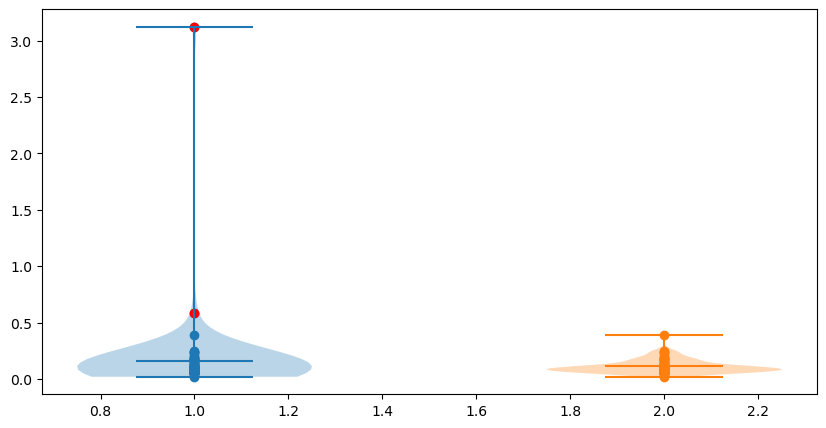

chr19 S19_2
6 Outlier values: [0.519077  0.411037  0.0172159 0.297358  0.297731  0.328124 ]
mean before outlier removal= 0.18
mean after outlier removal= 0.14


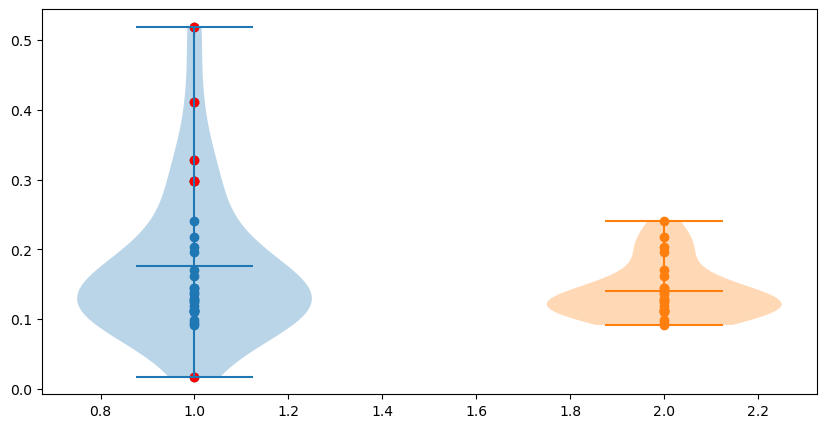

chr12 S12_1
6 Outlier values: [0.0511147 0.0612    0.0599693 0.0416445 0.0837627 0.104386 ]
mean before outlier removal= 0.02
mean after outlier removal= 0.02


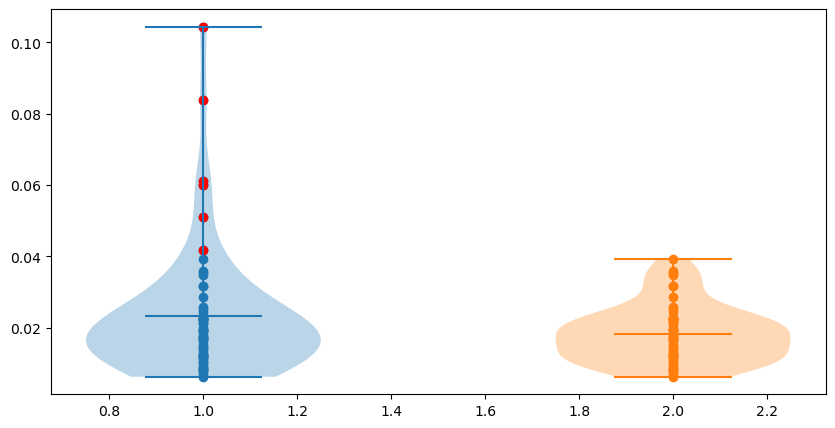

chr12 S12_2.1
12 Outlier values: [0.0514987  0.0285509  0.00132296 0.0193674  0.0297767  0.0195617
 0.0276173  0.0319567  0.0222357  0.0212116  0.0295643  0.0437557 ]
mean before outlier removal= 0.01
mean after outlier removal= 0.01


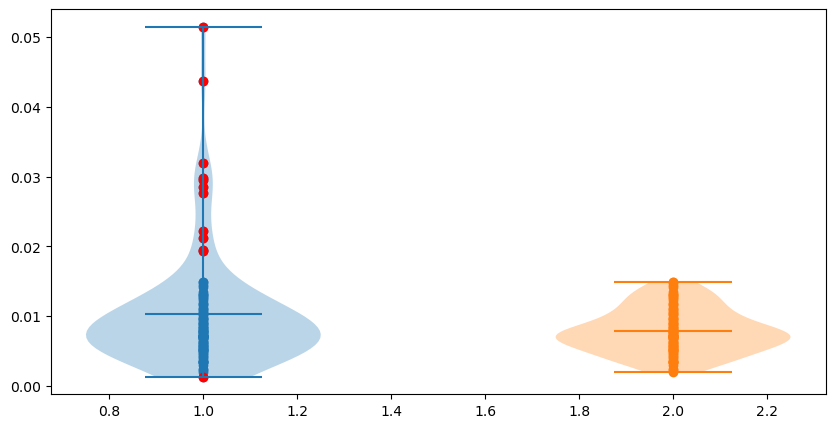

chr12 S12_2_Rec
1 Outlier values: [0.323097]
mean before outlier removal= 0.02
mean after outlier removal= 0.01


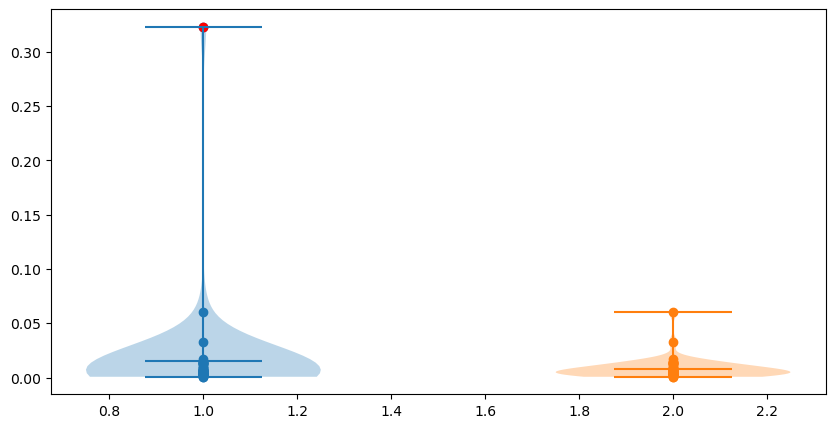

chr12 S12_2.2
10 Outlier values: [0.0437025 0.0415217 0.0257411 0.0267159 0.0268455 0.0218039 0.0320405
 0.0794396 0.0278126 0.0207459]
mean before outlier removal= 0.01
mean after outlier removal= 0.01


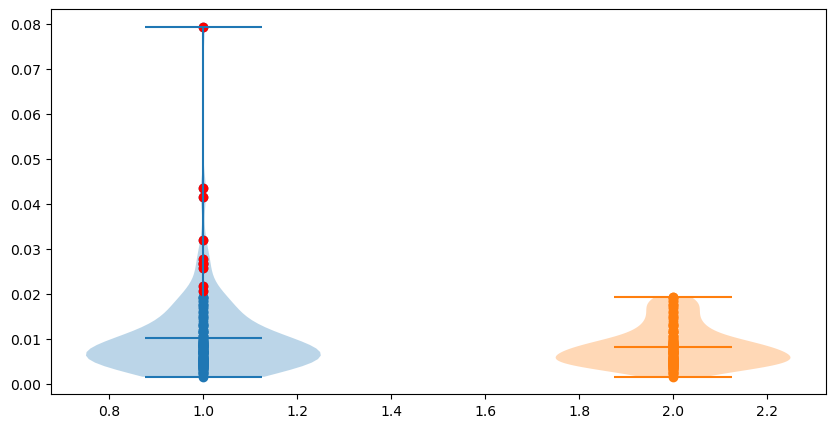

chr12 S12_3
3 Outlier values: [0.47877   0.0853851 0.159344 ]
mean before outlier removal= 0.01
mean after outlier removal= 0.01


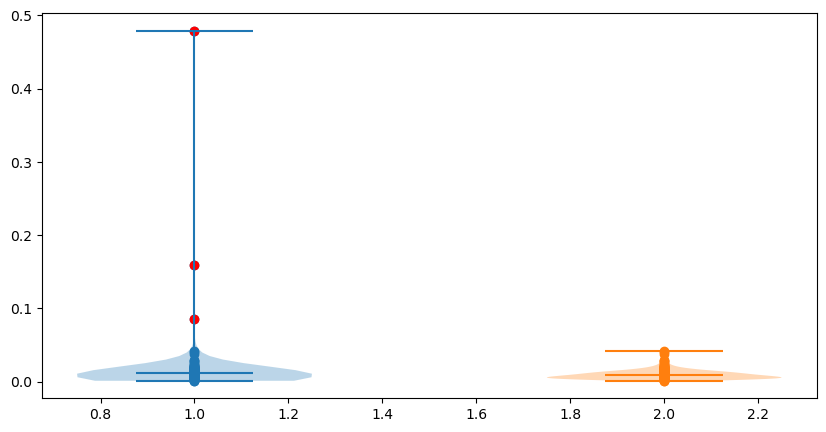

In [24]:
for chrom in Gw_dS_per_strata_dict:
    for stratum in Gw_dS_per_strata_dict[chrom]:
        print(chrom, stratum)
        Gw_dS_per_strata_dict[chrom][stratum]["dS_remv_outliers"] = remove_outlier_dS(Gw_dS_per_strata_dict[chrom][stratum]["dS"], 1)

Now get the number of genes that have been lost in each stratum

In [25]:
### Get all gene positions 

Gw_gff_path = "/Users/dj20y461/Downloads/Gw.AX.longest.gff"

Gw_all_genes_dict = {}
Gw_gene_dict = {}

with open(Gw_gff_path) as Gw_gff:

    for line in Gw_gff:
        
        if not line.startswith("#"):
        
            if line.split()[2] == "mRNA":
                info_line = line.split()[8]

                for field in info_line.split(";"):
                    if field.startswith("ID"):
                        gene_name = field.split("=")[1]
                        gene_start = line.split()[3]
                        gene_end = line.split()[4]
                        gene_chrom = line.split()[0]

                Gw_all_genes_dict[gene_name] = {}
                Gw_all_genes_dict[gene_name]["start"] = int(gene_start)
                Gw_all_genes_dict[gene_name]["end"] = int(gene_end)
                Gw_all_genes_dict[gene_name]["chrom"] = gene_chrom
                
                
                if line.split()[0] in ["chr12","chr19"]:      
                    Gw_gene_dict[gene_name] = {}
                    Gw_gene_dict[gene_name]["start"] = int(gene_start)
                    Gw_gene_dict[gene_name]["end"] = int(gene_end)
                    Gw_gene_dict[gene_name]["chrom"] = gene_chrom


In [26]:
### Get all gene positions 

Ga_gff_path = "/Users/dj20y461/Downloads/Ga.longest.gff3"
chr19_refseqID="NC_053230.1"

Ga_gene_dict = {}
Ga_chr19_gene_dict = {}

with open(Ga_gff_path) as Ga_gff:

    for line in Ga_gff:
        
        if not line.startswith("#"):
        
            if line.split()[2] == "mRNA":
                info_line = line.split()[8]

                for field in info_line.split(";"):
                    if field.startswith("ID"):
                        gene_name = field.split("=")[1]
                        gene_start = line.split()[3]
                        gene_end = line.split()[4]
                        
                Ga_gene_dict[gene_name] = {}
                Ga_gene_dict[gene_name]["start"] = int(gene_start)
                Ga_gene_dict[gene_name]["end"] = int(gene_end)
                
                if line.split()[0] == chr19_refseqID:

                    Ga_chr19_gene_dict[gene_name] = {}
                    Ga_chr19_gene_dict[gene_name]["start"] = int(gene_start)
                    Ga_chr19_gene_dict[gene_name]["end"] = int(gene_end)

In [27]:
len(Gw_gene_dict)

2178

In [28]:
## bin genes into their strata

Gw_Genes_per_stratum = {}

for chrom in Gw_strata:
    for stratum in Gw_strata[chrom]:
        Gw_Genes_per_stratum[stratum] = []

for gene in Gw_gene_dict:
    
    for chrom in Gw_strata:
        
        if Gw_gene_dict[gene]["chrom"] == chrom:
        
            for stratum in Gw_strata[chrom]:

                if Gw_strata[chrom][stratum][0] < Gw_gene_dict[gene]["start"] <= Gw_strata[chrom][stratum][1]:
                    Gw_Genes_per_stratum[stratum].append(gene)
    
    

In [29]:
total_gene_count = 0
for stratum in Gw_Genes_per_stratum:
    print(stratum, len(Gw_Genes_per_stratum[stratum]))
    total_gene_count += len(Gw_Genes_per_stratum[stratum])
    
print(total_gene_count)

S19_1 581
S19_2 491
S12_1 78
S12_2.1 135
S12_2_Rec 88
S12_2.2 188
S12_3 325
PAR 292
2178


In [30]:
Gw_gene_groups_path = "/Users/dj20y461/Data_temp/Stickleback/Stickle_Y_comp/results_2025/99.misc/Gene.groups/Gw.gene.groups"

Gw_gene_status = {}

with open(Gw_gene_groups_path) as Gw_gene_groups:
    
    header = next(Gw_gene_groups)
    
    for line in Gw_gene_groups:

        line = line.strip()
        
        gene_name = line.split()[0]
        
        Gw_gene_status[gene_name] = {}
        Gw_gene_status[gene_name]["status"] = line.split("\t")[2]


In [31]:
for gene in Gw_gene_status:
    
    if gene in Gw_gene_dict:
        
        Gw_gene_status[gene]["start"] = Gw_gene_dict[gene]["start"]
        Gw_gene_status[gene]["chrom"] = Gw_gene_dict[gene]["chrom"]
    

finally add the stratas

In [32]:
for gene in Gw_gene_status:
    for chrom in Gw_strata:
        for stratum in Gw_strata[chrom]:
            if Gw_gene_status[gene]["chrom"] == chrom:
                if Gw_strata[chrom][stratum][0] < Gw_gene_status[gene]["start"] <= Gw_strata[chrom][stratum][1]: 
                    Gw_gene_status[gene]["stratum"] = stratum

Now plot the data

In [33]:
## Plotting all 1n genes first

Gw_x = {}
strata = ["S19_1", "S19_2", 
          "S12_1", 
          "S12_2.1", "S12_2_Rec", "S12_2.2", 
          "S12_3"]

for chrom in Gw_dS_per_strata_dict:
    for stratum in Gw_dS_per_strata_dict[chrom]:
        Gw_x[stratum]= {}
        Gw_x[stratum]["mean"] = np.mean(Gw_dS_per_strata_dict[chrom][stratum]['dS_remv_outliers'])
        Gw_x[stratum]["std"] = np.std(Gw_dS_per_strata_dict[chrom][stratum]['dS_remv_outliers'])
    
    
Gw_y = {}

for chrom in Gw_dS_per_strata_dict:
    for stratum in Gw_dS_per_strata_dict[chrom]:
        count_1n = 0
        count_stratum_total = 0
        for gene in Gw_gene_status:
            if Gw_gene_status[gene]["stratum"] == stratum:
                count_stratum_total += 1
                if Gw_gene_status[gene]["status"] == "1n":
                    count_1n += 1
        print(stratum, count_1n, count_stratum_total, len(Gw_Genes_per_stratum[stratum]))
        Gw_y[stratum] = count_1n/count_stratum_total


S19_1 419 489 581
S19_2 424 453 491
S12_1 9 70 78
S12_2.1 11 124 135
S12_2_Rec 3 82 88
S12_2.2 8 175 188
S12_3 9 304 325


In [34]:
## Now plotting all 1n AND 1n-2n

Gw_x_all_lost = {}
strata = ["S19_1", "S19_2", 
          "S12_1", 
          "S12_2.1", "S12_2_Rec", "S12_2.2", 
          "S12_3"]

for chrom in Gw_dS_per_strata_dict:
    for stratum in Gw_dS_per_strata_dict[chrom]:
        Gw_x_all_lost[stratum]= {}
        Gw_x_all_lost[stratum]["mean"] = np.mean(Gw_dS_per_strata_dict[chrom][stratum]['dS_remv_outliers'])
        Gw_x_all_lost[stratum]["std"] = np.std(Gw_dS_per_strata_dict[chrom][stratum]['dS_remv_outliers'])
    
Gw_y_all_lost = {}

for chrom in Gw_dS_per_strata_dict:
    for stratum in Gw_dS_per_strata_dict[chrom]:
        count_1n = 0
        count_stratum_total = 0
        for gene in Gw_gene_status:
            if Gw_gene_status[gene]["stratum"] == stratum:
                count_stratum_total += 1
                if Gw_gene_status[gene]["status"] in ["1n", "1n-2n"]:
                    count_1n += 1
        print(stratum, count_1n, count_stratum_total, len(Gw_Genes_per_stratum[stratum]))
        Gw_y_all_lost[stratum] = count_1n/count_stratum_total


S19_1 474 489 581
S19_2 443 453 491
S12_1 34 70 78
S12_2.1 39 124 135
S12_2_Rec 37 82 88
S12_2.2 53 175 188
S12_3 95 304 325


### Plotting

#### 1n genes only

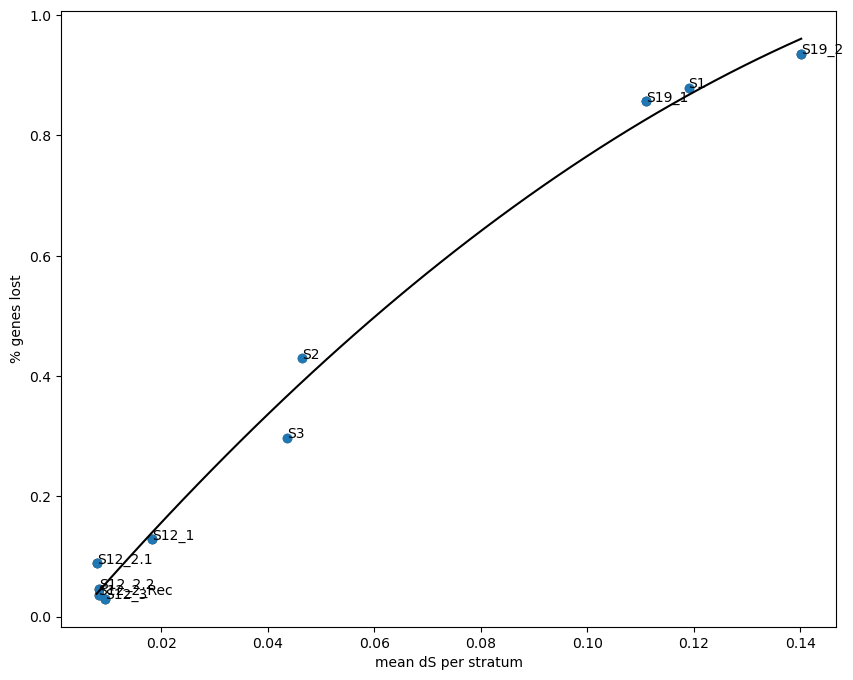

In [35]:
plt.figure(figsize = (10,8))

Gw_x_fit = [] 
Gw_y_fit = []

for stratum in Gw_x:
    plt.scatter(Gw_x[stratum]["mean"],
                Gw_y[stratum],
                color = "black")
    plt.text(Gw_x[stratum]["mean"],
             Gw_y[stratum],
             stratum)

    Gw_x_fit.append(Gw_x[stratum]["mean"])
    Gw_y_fit.append(Gw_y[stratum])
    
Ga_x_fit = [] 
Ga_y_fit = []

for stratum in Ga_x:
    plt.scatter(Ga_x[stratum]["mean"],
                Ga_y[stratum], 
                color = "grey")
    plt.text(Ga_x[stratum]["mean"],
             Ga_y[stratum], 
             stratum)
    
    Ga_x_fit.append(Ga_x[stratum]["mean"])
    Ga_y_fit.append(Ga_y[stratum])
    
    
## sorting to fit polynomial (doing this manually is lazy, but works)    

combined_x_sorted = Gw_x_fit[3], Gw_x_fit[4], Gw_x_fit[5], Gw_x_fit[6], Gw_x_fit[2],Ga_x_fit[2], Ga_x_fit[1], Gw_x_fit[0],Ga_x_fit[0], Gw_x_fit[1]
combined_y_sorted = Gw_y_fit[3], Gw_y_fit[4], Gw_y_fit[5], Gw_y_fit[6], Gw_y_fit[2],Ga_y_fit[2], Ga_y_fit[1], Gw_y_fit[0],Ga_y_fit[0], Gw_y_fit[1]
    
# calculate polynomial
z = np.polyfit(combined_x_sorted, combined_y_sorted, 2)
f = np.poly1d(z)

# calculate new x's and y's
x_new = np.linspace(combined_x_sorted[0], combined_x_sorted[-1], 50)
y_new = f(x_new)

plt.plot(combined_x_sorted,combined_y_sorted,'o', x_new, y_new, "black")
  
    
plt.xlabel("mean dS per stratum")
plt.ylabel("% genes lost")

plt.savefig("/Users/dj20y461/Data_temp/Stickleback/Stickle_Y_comp/plots/gene_loss/1n_genes_per_stratum.pdf")
plt.show()

With 1n genes only, there is a pretty linear relationship between age and gene loss

#### 1n + 1n-2n genes

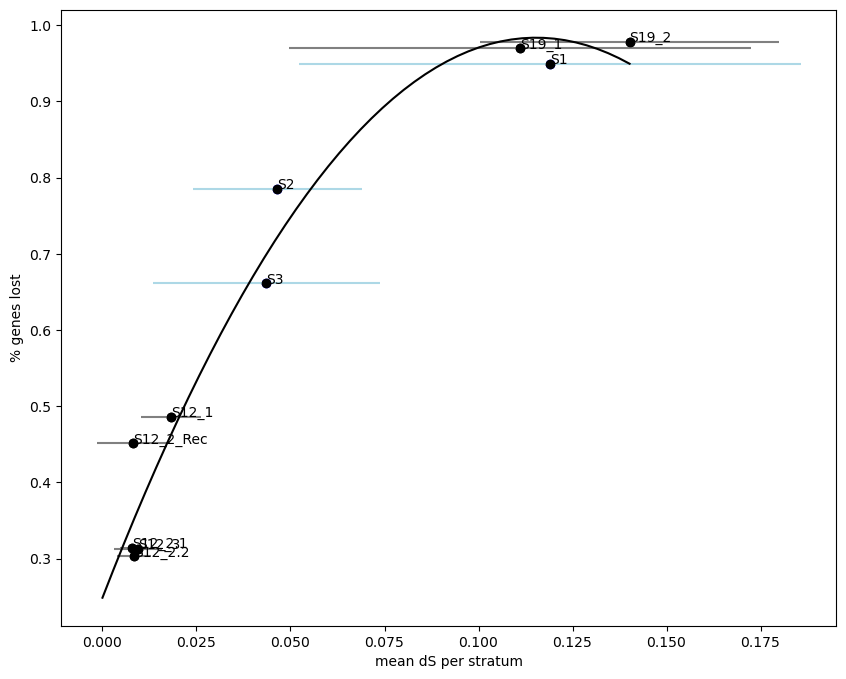

In [36]:
plt.figure(figsize = (10,8))

Gw_x_fit = [] 
Gw_y_fit = []

for stratum in Gw_x_all_lost:
    plt.scatter(Gw_x_all_lost[stratum]["mean"],
                Gw_y_all_lost[stratum], 
                color = "black")
    plt.hlines(Gw_y_all_lost[stratum],
               Gw_x_all_lost[stratum]["mean"]-Gw_x_all_lost[stratum]["std"],
               Gw_x_all_lost[stratum]["mean"]+Gw_x_all_lost[stratum]["std"],
               color = "grey")
    
    Gw_x_fit.append(Gw_x_all_lost[stratum]["mean"])
    Gw_y_fit.append(Gw_y_all_lost[stratum])
    
    plt.text(Gw_x_all_lost[stratum]["mean"],
             Gw_y_all_lost[stratum],
             stratum)
    
Ga_x_fit = [] 
Ga_y_fit = []    

for stratum in Ga_x_all_lost:
    plt.scatter(Ga_x_all_lost[stratum]["mean"],
                Ga_y_all_lost[stratum], 
                color = "blue")
    plt.hlines(Ga_y_all_lost[stratum],
               Ga_x_all_lost[stratum]["mean"]-Ga_x_all_lost[stratum]["std"],
               Ga_x_all_lost[stratum]["mean"]+Ga_x_all_lost[stratum]["std"],
               color = "lightblue")
    
    Ga_x_fit.append(Ga_x_all_lost[stratum]["mean"])
    Ga_y_fit.append(Ga_y_all_lost[stratum])
    
    plt.text(Ga_x_all_lost[stratum]["mean"],
             Ga_y_all_lost[stratum], 
             stratum)


## sorting to fit COMBINED polynomial (doing this manually is lazy, but works)    

combined_x_sorted = Gw_x_fit[3], Gw_x_fit[4], Gw_x_fit[5], Gw_x_fit[6], Gw_x_fit[2],Ga_x_fit[2], Ga_x_fit[1], Gw_x_fit[0],Ga_x_fit[0], Gw_x_fit[1]
combined_y_sorted = Gw_y_fit[3], Gw_y_fit[4], Gw_y_fit[5], Gw_y_fit[6], Gw_y_fit[2],Ga_y_fit[2], Ga_y_fit[1], Gw_y_fit[0],Ga_y_fit[0], Gw_y_fit[1]
    
# calculate polynomial
z = np.polyfit(combined_x_sorted, combined_y_sorted, 2)
f = np.poly1d(z)

# calculate new x's and y's
x_new = np.linspace(0, combined_x_sorted[-1], 50)
y_new = f(x_new)

plt.plot(combined_x_sorted,combined_y_sorted,'o', x_new, y_new, color = "black")
    
plt.xlabel("mean dS per stratum")
plt.ylabel("% genes lost")

plt.savefig("/Users/dj20y461/Data_temp/Stickleback/Stickle_Y_comp/plots/gene_loss/1n_and_1n-2n_genes_per_stratum.pdf")
plt.show()

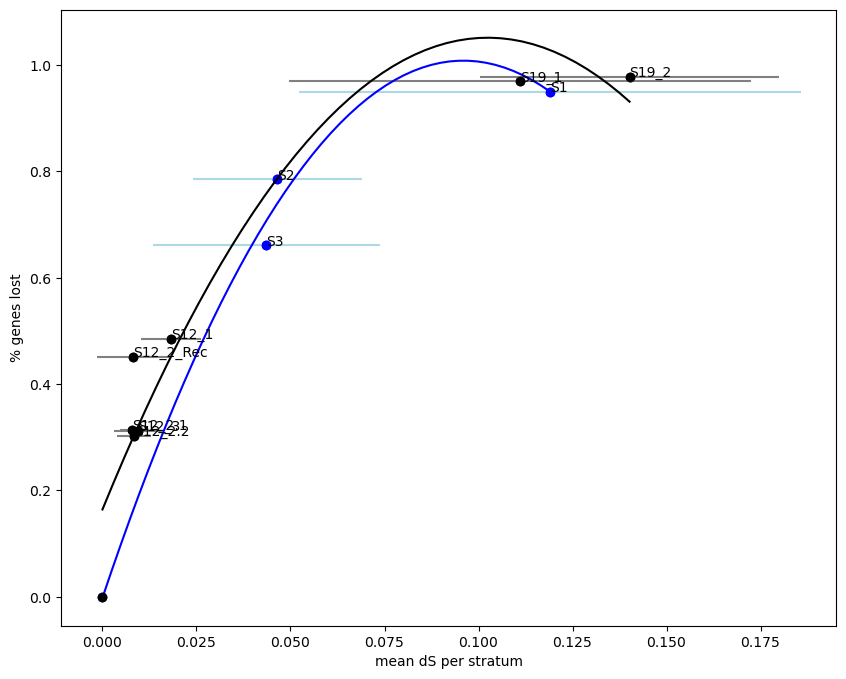

In [37]:
plt.figure(figsize = (10,8))

Gw_x_fit = [] 
Gw_y_fit = []

for stratum in Gw_x_all_lost:
    plt.scatter(Gw_x_all_lost[stratum]["mean"],
                Gw_y_all_lost[stratum], 
                color = "black")
    plt.hlines(Gw_y_all_lost[stratum],
               Gw_x_all_lost[stratum]["mean"]-Gw_x_all_lost[stratum]["std"],
               Gw_x_all_lost[stratum]["mean"]+Gw_x_all_lost[stratum]["std"],
               color = "grey")
    
    Gw_x_fit.append(Gw_x_all_lost[stratum]["mean"])
    Gw_y_fit.append(Gw_y_all_lost[stratum])
    
    plt.text(Gw_x_all_lost[stratum]["mean"],
             Gw_y_all_lost[stratum],
             stratum)
    
Ga_x_fit = [] 
Ga_y_fit = []    

for stratum in Ga_x_all_lost:
    plt.scatter(Ga_x_all_lost[stratum]["mean"],
                Ga_y_all_lost[stratum], 
                color = "blue")
    plt.hlines(Ga_y_all_lost[stratum],
               Ga_x_all_lost[stratum]["mean"]-Ga_x_all_lost[stratum]["std"],
               Ga_x_all_lost[stratum]["mean"]+Ga_x_all_lost[stratum]["std"],
               color = "lightblue")
    
    Ga_x_fit.append(Ga_x_all_lost[stratum]["mean"])
    Ga_y_fit.append(Ga_y_all_lost[stratum])
    
    plt.text(Ga_x_all_lost[stratum]["mean"],
             Ga_y_all_lost[stratum], 
             stratum)

## sorting to fit polynomial for Ga (doing this manually is lazy, but works)    
combined_x_sorted = 0, Ga_x_fit[2], Ga_x_fit[1], Ga_x_fit[0]
combined_y_sorted = 0, Ga_y_fit[2], Ga_y_fit[1], Ga_y_fit[0]

# calculate polynomial
z = np.polyfit(combined_x_sorted, combined_y_sorted, 2)
f = np.poly1d(z)

# calculate new x's and y's
x_new = np.linspace(0, combined_x_sorted[-1], 50)
y_new = f(x_new)

plt.plot(combined_x_sorted,combined_y_sorted,'o', x_new, y_new, color = "blue")


## sorting to fit polynomial for Gw (doing this manually is lazy, but works)    
combined_x_sorted = 0, Gw_x_fit[3], Gw_x_fit[4], Gw_x_fit[5], Gw_x_fit[6], Gw_x_fit[2], Gw_x_fit[0], Gw_x_fit[1]
combined_y_sorted = 0, Gw_y_fit[3], Gw_y_fit[4], Gw_y_fit[5], Gw_y_fit[6], Gw_y_fit[2], Gw_y_fit[0], Gw_y_fit[1]

# calculate polynomial
z = np.polyfit(combined_x_sorted, combined_y_sorted, 2
              )
f = np.poly1d(z)

# calculate new x's and y's
x_new = np.linspace(0, combined_x_sorted[-1], 50)
y_new = f(x_new)

plt.plot(combined_x_sorted,combined_y_sorted,'o', x_new, y_new, color = "black")
    
    
## sorting to fit COMBINED polynomial (doing this manually is lazy, but works)    

combined_x_sorted = 0, Gw_x_fit[3], Gw_x_fit[4], Gw_x_fit[5], Gw_x_fit[6], Gw_x_fit[2],Ga_x_fit[2], Ga_x_fit[1], Gw_x_fit[0],Ga_x_fit[0], Gw_x_fit[1]
combined_y_sorted = 0, Gw_y_fit[3], Gw_y_fit[4], Gw_y_fit[5], Gw_y_fit[6], Gw_y_fit[2],Ga_y_fit[2], Ga_y_fit[1], Gw_y_fit[0],Ga_y_fit[0], Gw_y_fit[1]
    
# calculate polynomial
z = np.polyfit(combined_x_sorted, combined_y_sorted, 2)
f = np.poly1d(z)

# calculate new x's and y's
x_new = np.linspace(0, combined_x_sorted[-1], 50)
y_new = f(x_new)

#plt.plot(combined_x_sorted,combined_y_sorted,'o', x_new, y_new, color = "black")
    
plt.xlabel("mean dS per stratum")
plt.ylabel("% genes lost")

plt.savefig("/Users/dj20y461/Data_temp/Stickleback/Stickle_Y_comp/plots/gene_loss/1n_and_1n-2n_genes_per_stratum.pdf")
plt.show()

#### Plot these as genes retained rather than lost - this is how the literature deals with it. 

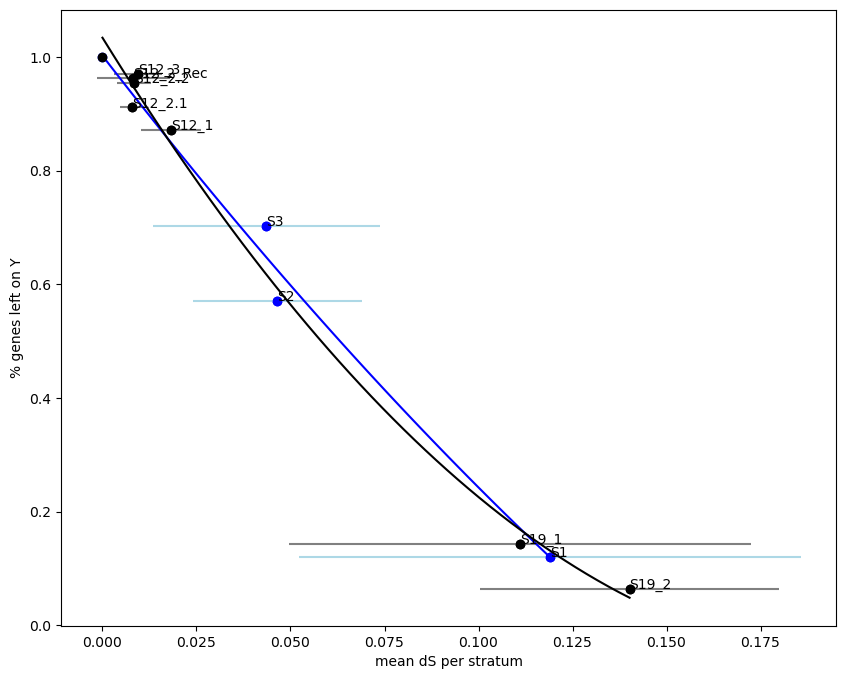

In [38]:
## 1n only

plt.figure(figsize = (10,8))

Gw_x_fit = [] 
Gw_y_fit = []

for stratum in Gw_x:
    plt.scatter(Gw_x[stratum]["mean"],
                1-Gw_y[stratum], 
                color = "black")
    plt.hlines(1-Gw_y[stratum],
               Gw_x[stratum]["mean"]-Gw_x[stratum]["std"],
               Gw_x[stratum]["mean"]+Gw_x[stratum]["std"],
               color = "grey")
    
    Gw_x_fit.append(Gw_x[stratum]["mean"])
    Gw_y_fit.append(Gw_y[stratum])
    
    plt.text(Gw_x[stratum]["mean"],
             1-Gw_y[stratum],
             stratum)
    
Ga_x_fit = [] 
Ga_y_fit = []    

for stratum in Ga_x:
    plt.scatter(Ga_x[stratum]["mean"],
                1-Ga_y[stratum], 
                color = "blue")
    plt.hlines(1-Ga_y[stratum],
               Ga_x[stratum]["mean"]-Ga_x[stratum]["std"],
               Ga_x[stratum]["mean"]+Ga_x[stratum]["std"],
               color = "lightblue")
    
    Ga_x_fit.append(Ga_x[stratum]["mean"])
    Ga_y_fit.append(Ga_y[stratum])
    
    plt.text(Ga_x[stratum]["mean"],
             1-Ga_y[stratum], 
             stratum)

Ga_y_fit = [1-i for i in Ga_y_fit]
Gw_y_fit = [1-i for i in Gw_y_fit]
    
## sorting to fit polynomial for Ga (doing this manually is lazy, but works)    
combined_x_sorted = 0, Ga_x_fit[2], Ga_x_fit[1], Ga_x_fit[0]
combined_y_sorted = 1, Ga_y_fit[2], Ga_y_fit[1], Ga_y_fit[0]

# calculate polynomial
z = np.polyfit(combined_x_sorted, combined_y_sorted, 2)
f = np.poly1d(z)

# calculate new x's and y's
x_new = np.linspace(0, combined_x_sorted[-1], 50)
y_new = f(x_new)

plt.plot(combined_x_sorted,combined_y_sorted,'o', x_new, y_new, color = "blue")


## sorting to fit polynomial for Gw (doing this manually is lazy, but works)    
combined_x_sorted = 0, Gw_x_fit[3], Gw_x_fit[4], Gw_x_fit[5], Gw_x_fit[6], Gw_x_fit[2], Gw_x_fit[0], Gw_x_fit[1]
combined_y_sorted = 1, Gw_y_fit[3], Gw_y_fit[4], Gw_y_fit[5], Gw_y_fit[6], Gw_y_fit[2], Gw_y_fit[0], Gw_y_fit[1]

# calculate polynomial
z = np.polyfit(combined_x_sorted, combined_y_sorted, 2)
f = np.poly1d(z)

# calculate new x's and y's
x_new = np.linspace(0, combined_x_sorted[-1], 50)
y_new = f(x_new)

plt.plot(combined_x_sorted,combined_y_sorted,'o', x_new, y_new, color = "black")
    
    
## sorting to fit COMBINED polynomial (doing this manually is lazy, but works)    

combined_x_sorted = 0, Gw_x_fit[3], Gw_x_fit[4], Gw_x_fit[5], Gw_x_fit[6], Gw_x_fit[2],Ga_x_fit[2], Ga_x_fit[1], Gw_x_fit[0],Ga_x_fit[0], Gw_x_fit[1]
combined_y_sorted = 0, Gw_y_fit[3], Gw_y_fit[4], Gw_y_fit[5], Gw_y_fit[6], Gw_y_fit[2],Ga_y_fit[2], Ga_y_fit[1], Gw_y_fit[0],Ga_y_fit[0], Gw_y_fit[1]
    
# calculate polynomial
z = np.polyfit(combined_x_sorted, combined_y_sorted, 2)
f = np.poly1d(z)

# calculate new x's and y's
x_new = np.linspace(0, combined_x_sorted[-1], 50)
y_new = f(x_new)

#plt.plot(combined_x_sorted,combined_y_sorted,'o', x_new, y_new, color = "black")
    
plt.xlabel("mean dS per stratum")
plt.ylabel("% genes left on Y")

plt.savefig("/Users/dj20y461/Data_temp/Stickleback/Stickle_Y_comp/plots/gene_loss/1n_and_1n-2n_genes_per_stratum.pdf")
plt.show()

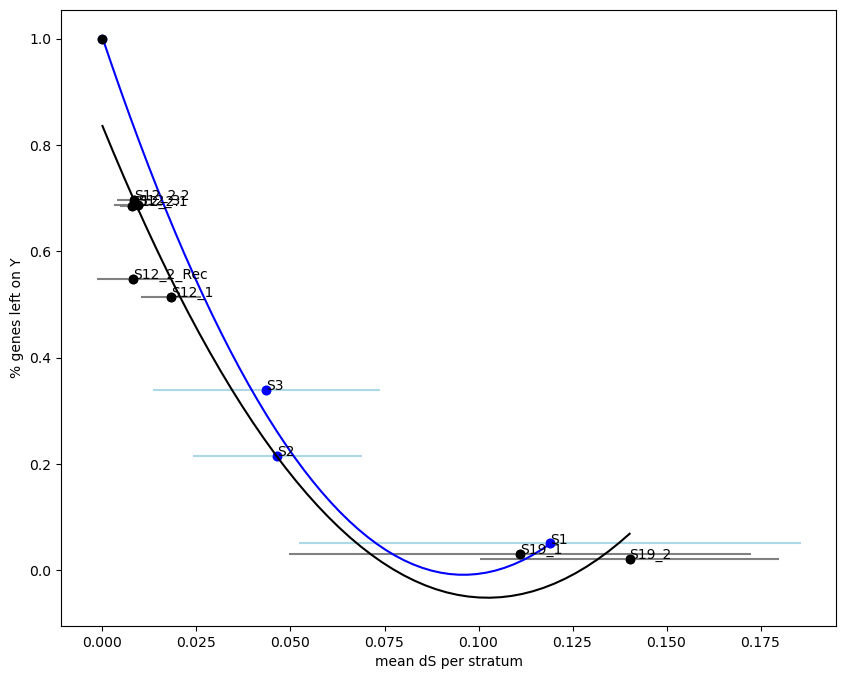

In [39]:
plt.figure(figsize = (10,8))

Gw_x_fit = [] 
Gw_y_fit = []

for stratum in Gw_x_all_lost:
    plt.scatter(Gw_x_all_lost[stratum]["mean"],
                1-Gw_y_all_lost[stratum], 
                color = "black")
    plt.hlines(1-Gw_y_all_lost[stratum],
               Gw_x_all_lost[stratum]["mean"]-Gw_x_all_lost[stratum]["std"],
               Gw_x_all_lost[stratum]["mean"]+Gw_x_all_lost[stratum]["std"],
               color = "grey")
    
    Gw_x_fit.append(Gw_x_all_lost[stratum]["mean"])
    Gw_y_fit.append(Gw_y_all_lost[stratum])
    
    plt.text(Gw_x_all_lost[stratum]["mean"],
             1-Gw_y_all_lost[stratum],
             stratum)
    
Ga_x_fit = [] 
Ga_y_fit = []    

for stratum in Ga_x_all_lost:
    plt.scatter(Ga_x_all_lost[stratum]["mean"],
                1-Ga_y_all_lost[stratum], 
                color = "blue")
    plt.hlines(1-Ga_y_all_lost[stratum],
               Ga_x_all_lost[stratum]["mean"]-Ga_x_all_lost[stratum]["std"],
               Ga_x_all_lost[stratum]["mean"]+Ga_x_all_lost[stratum]["std"],
               color = "lightblue")
    
    Ga_x_fit.append(Ga_x_all_lost[stratum]["mean"])
    Ga_y_fit.append(Ga_y_all_lost[stratum])
    
    plt.text(Ga_x_all_lost[stratum]["mean"],
             1-Ga_y_all_lost[stratum], 
             stratum)

Ga_y_fit = [1-i for i in Ga_y_fit]
Gw_y_fit = [1-i for i in Gw_y_fit]
    
## sorting to fit polynomial for Ga (doing this manually is lazy, but works)    
combined_x_sorted = 0, Ga_x_fit[2], Ga_x_fit[1], Ga_x_fit[0]
combined_y_sorted = 1, Ga_y_fit[2], Ga_y_fit[1], Ga_y_fit[0]

# calculate polynomial
z = np.polyfit(combined_x_sorted, combined_y_sorted, 2)
f = np.poly1d(z)

# calculate new x's and y's
x_new = np.linspace(0, combined_x_sorted[-1], 50)
y_new = f(x_new)

plt.plot(combined_x_sorted,combined_y_sorted,'o', x_new, y_new, color = "blue")


## sorting to fit polynomial for Gw (doing this manually is lazy, but works)    
combined_x_sorted = 0, Gw_x_fit[3], Gw_x_fit[4], Gw_x_fit[5], Gw_x_fit[6], Gw_x_fit[2], Gw_x_fit[0], Gw_x_fit[1]
combined_y_sorted = 1, Gw_y_fit[3], Gw_y_fit[4], Gw_y_fit[5], Gw_y_fit[6], Gw_y_fit[2], Gw_y_fit[0], Gw_y_fit[1]

# calculate polynomial
z = np.polyfit(combined_x_sorted, combined_y_sorted, 2)
f = np.poly1d(z)

# calculate new x's and y's
x_new = np.linspace(0, combined_x_sorted[-1], 50)
y_new = f(x_new)

plt.plot(combined_x_sorted,combined_y_sorted,'o', x_new, y_new, color = "black")
    
    
## sorting to fit COMBINED polynomial (doing this manually is lazy, but works)    

combined_x_sorted = 0, Gw_x_fit[3], Gw_x_fit[4], Gw_x_fit[5], Gw_x_fit[6], Gw_x_fit[2],Ga_x_fit[2], Ga_x_fit[1], Gw_x_fit[0],Ga_x_fit[0], Gw_x_fit[1]
combined_y_sorted = 0, Gw_y_fit[3], Gw_y_fit[4], Gw_y_fit[5], Gw_y_fit[6], Gw_y_fit[2],Ga_y_fit[2], Ga_y_fit[1], Gw_y_fit[0],Ga_y_fit[0], Gw_y_fit[1]
    
# calculate polynomial
z = np.polyfit(combined_x_sorted, combined_y_sorted, 2)
f = np.poly1d(z)

# calculate new x's and y's
x_new = np.linspace(0, combined_x_sorted[-1], 50)
y_new = f(x_new)

#plt.plot(combined_x_sorted,combined_y_sorted,'o', x_new, y_new, color = "black")
    
plt.xlabel("mean dS per stratum")
plt.ylabel("% genes left on Y")

plt.savefig("/Users/dj20y461/Data_temp/Stickleback/Stickle_Y_comp/plots/gene_loss/1n_and_1n-2n_genes_per_stratum.pdf")
plt.show()

### Trying a different model fitting

In [48]:
# 1. Define the exponential decay function
def exponential_decay(x, A, k, C):
    """
    Exponential decay function: y = A * exp(-k * x) + C
    A: Amplitude
    k: Decay constant
    C: Offset (asymptotic value)
    """
    return A * np.exp(-k * x) + C

In [55]:
initial_guesses = [max(combined_y_sorted) - min(combined_y_sorted), 0.5, min(combined_y_sorted)]


In [56]:
params, covariance = curve_fit(exponential_decay, combined_x_sorted, combined_y_sorted, p0=initial_guesses)

# Extract the fitted parameters
A_fit, k_fit, C_fit = params

print("Fitted parameters:")
print(f"  A (Amplitude): {A_fit:.2f}")
print(f"  k (Decay Constant): {k_fit:.4f}") # k is often small, so more decimal places
print(f"  C (Offset/Asymptote): {C_fit:.2f}")

Fitted parameters:
  A (Amplitude): 0.88
  k (Decay Constant): 33.1213
  C (Offset/Asymptote): 0.03


In [57]:
x_model = np.linspace(min(combined_x_sorted), max(combined_x_sorted), 500)
y_model = exponential_decay(x_model, A_fit, k_fit, C_fit)

Fitted parameters:
  A (Amplitude): 0.94
  k (Decay Constant): 42.7858
  C (Offset/Asymptote): 0.02
Fitted parameters:
  A (Amplitude): 0.98
  k (Decay Constant): 29.6150
  C (Offset/Asymptote): 0.02


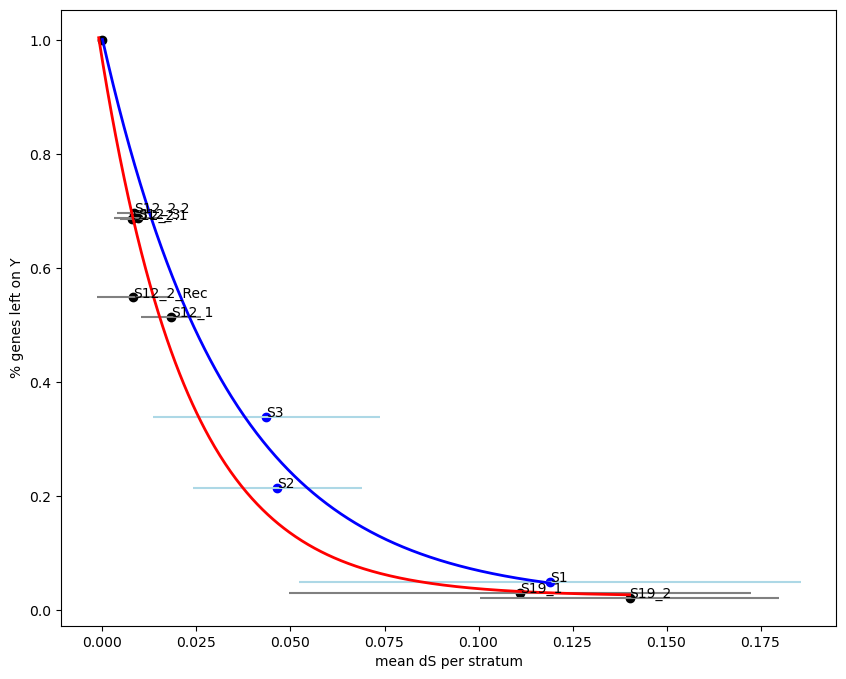

In [70]:
plt.figure(figsize = (10,8))

Gw_x_fit = [] 
Gw_y_fit = []

for stratum in Gw_x_all_lost:
    plt.scatter(Gw_x_all_lost[stratum]["mean"],
                1-Gw_y_all_lost[stratum], 
                color = "black")
    plt.hlines(1-Gw_y_all_lost[stratum],
               Gw_x_all_lost[stratum]["mean"]-Gw_x_all_lost[stratum]["std"],
               Gw_x_all_lost[stratum]["mean"]+Gw_x_all_lost[stratum]["std"],
               color = "grey")
    
    Gw_x_fit.append(Gw_x_all_lost[stratum]["mean"])
    Gw_y_fit.append(Gw_y_all_lost[stratum])
    
    plt.text(Gw_x_all_lost[stratum]["mean"],
             1-Gw_y_all_lost[stratum],
             stratum)
    
Ga_x_fit = [] 
Ga_y_fit = []    

for stratum in Ga_x_all_lost:
    plt.scatter(Ga_x_all_lost[stratum]["mean"],
                1-Ga_y_all_lost[stratum], 
                color = "blue")
    plt.hlines(1-Ga_y_all_lost[stratum],
               Ga_x_all_lost[stratum]["mean"]-Ga_x_all_lost[stratum]["std"],
               Ga_x_all_lost[stratum]["mean"]+Ga_x_all_lost[stratum]["std"],
               color = "lightblue")
    
    Ga_x_fit.append(Ga_x_all_lost[stratum]["mean"])
    Ga_y_fit.append(Ga_y_all_lost[stratum])
    
    plt.text(Ga_x_all_lost[stratum]["mean"],
             1-Ga_y_all_lost[stratum], 
             stratum)
    
plt.scatter(0,1,
            color = "black")

Ga_y_fit = [1-i for i in Ga_y_fit]
Gw_y_fit = [1-i for i in Gw_y_fit]
    
## fit a model to the data for Gw

## sorting data before fitting model Gw (doing this manually is lazy, but works)    
combined_x_sorted = 0, Gw_x_fit[3], Gw_x_fit[4], Gw_x_fit[5], Gw_x_fit[6], Gw_x_fit[2], Gw_x_fit[0], Gw_x_fit[1]
combined_y_sorted = 1, Gw_y_fit[3], Gw_y_fit[4], Gw_y_fit[5], Gw_y_fit[6], Gw_y_fit[2], Gw_y_fit[0], Gw_y_fit[1]

## generate initial guesses for the parameters of the model
initial_guesses = [max(combined_y_sorted) - min(combined_y_sorted), 0.5, min(combined_y_sorted)]

params, covariance = curve_fit(exponential_decay, combined_x_sorted, combined_y_sorted, p0=initial_guesses)

# Extract the fitted parameters
A_fit, k_fit, C_fit = params

print("Fitted parameters:")
print(f"  A (Amplitude): {A_fit:.2f}")
print(f"  k (Decay Constant): {k_fit:.4f}") # k is often small, so more decimal places
print(f"  C (Offset/Asymptote): {C_fit:.2f}")

x_model = np.linspace(-0.001, max(combined_x_sorted), 500)
y_model = exponential_decay(x_model, A_fit, k_fit, C_fit)

## plot the model line 
plt.plot(x_model, y_model, color='red', linewidth=2, label='Fitted Exponential Decay Model')
    
## fit a model to the data for Ga

combined_x_sorted = 0, Ga_x_fit[2], Ga_x_fit[1], Ga_x_fit[0]
combined_y_sorted = 1, Ga_y_fit[2], Ga_y_fit[1], Ga_y_fit[0]

## generate initial guesses for the parameters of the model
initial_guesses = [max(combined_y_sorted) - min(combined_y_sorted), 0.5, min(combined_y_sorted)]

params, covariance = curve_fit(exponential_decay, combined_x_sorted, combined_y_sorted, p0=initial_guesses)

# Extract the fitted parameters
A_fit, k_fit, C_fit = params

print("Fitted parameters:")
print(f"  A (Amplitude): {A_fit:.2f}")
print(f"  k (Decay Constant): {k_fit:.4f}") # k is often small, so more decimal places
print(f"  C (Offset/Asymptote): {C_fit:.2f}")

x_model = np.linspace(0, max(combined_x_sorted), 500)
y_model = exponential_decay(x_model, A_fit, k_fit, C_fit)

## plot the model line 
plt.plot(x_model, y_model, color='blue', linewidth=2, label='Fitted Exponential Decay Model')
    

plt.xlabel("mean dS per stratum")
plt.ylabel("% genes left on Y")

plt.savefig("/Users/dj20y461/Data_temp/Stickleback/Stickle_Y_comp/plots/gene_loss/1n_and_1n-2n_genes_per_stratum.pdf")
plt.show()

With 1n + 1-2n genes, there is a plateuing pattern of gene loss, as expected. 

### Gene loss per unit of time

We can also view the above as % genes lost per unit of time. In this case dS. 

## Gw


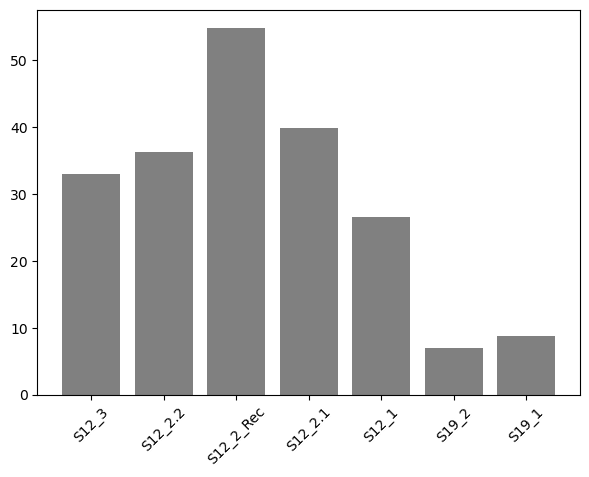

In [71]:
plt.figure(figsize = (7,5))
loss_per_time = {}

end_pos = 7
bar_pos = 1
labels = []
positions = []
for stratum in Gw_y_all_lost:
    LpT = Gw_y_all_lost[stratum]/Gw_x_all_lost[stratum]["mean"]
    loss_per_time[stratum] = LpT
    pos = end_pos - bar_pos
    plt.bar(pos, 
            LpT,
            color = "grey")
    
    positions.append(pos)
    labels.append(stratum)
    
    bar_pos += 1
    
plt.xticks(positions,labels, rotation = 45)
plt.show()

## Ga


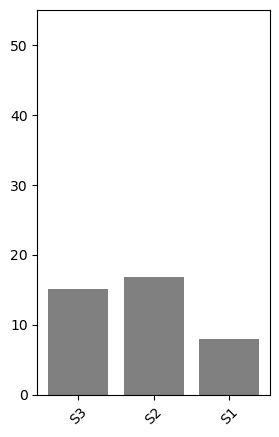

In [72]:
plt.figure(figsize = (3,5))
loss_per_time = {}

bar_pos = 1
labels = []
positions = []
for stratum in Ga_y_all_lost:
    LpT = Ga_y_all_lost[stratum]/Ga_x_all_lost[stratum]["mean"]
    loss_per_time[stratum] = LpT
    pos = end_pos - bar_pos
    plt.bar(pos, 
            LpT,
            color = "grey")
    
    positions.append(pos)
    labels.append(stratum)
    
    bar_pos += 1
    
plt.ylim(0,55)
plt.xticks(positions,labels, rotation = 45)
plt.show()

We could also try plotting rate against the age of the stratum. We are plotting dS against itself but it might be informative. Lets see. 

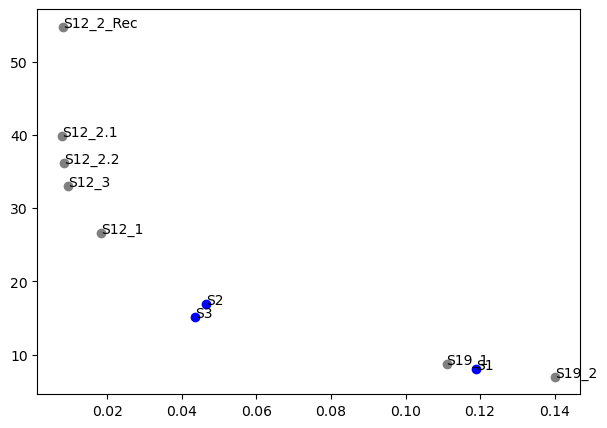

In [78]:
plt.figure(figsize = (7,5))
loss_per_time = {}

#Gw
for stratum in Gw_y_all_lost:
    LpT = Gw_y_all_lost[stratum]/Gw_x_all_lost[stratum]["mean"]
    loss_per_time[stratum] = LpT
    pos = end_pos - bar_pos
    plt.scatter(Gw_x_all_lost[stratum]["mean"],
                LpT,
                color = "grey")
    plt.text(Gw_x_all_lost[stratum]["mean"],
            LpT,
            stratum)
    
## Ga
for stratum in Ga_y_all_lost:
    LpT = Ga_y_all_lost[stratum]/Ga_x_all_lost[stratum]["mean"]
    loss_per_time[stratum] = LpT
    pos = end_pos - bar_pos
    plt.scatter(Ga_x_all_lost[stratum]["mean"],
                LpT,
                color = "blue")
    plt.text(Ga_x_all_lost[stratum]["mean"],
            LpT,
            stratum)
    
    
plt.savefig("/Users/dj20y461/Data_temp/Stickleback/Stickle_Y_comp/plots/gene_loss/loss_per_time_scatter.pdf")
plt.show()

Actually this is a really nice plot. The curve is almost perfect. Though perhaps that is because I am plotting geneloss/dS vs dS. Could keep it as a supplementary and see what others think later. 

# Testing for convergent gene retention across the sex chromosomes

What do I need?

- List of 2n genes on Ga
- List of 2n genes on Gw
- List of 1-1 orthologs between Ga and Gw. 

I already have gene status for both species. 

In [44]:
def Orthofiner_parser(N0_path):
    
    """
    This function parses the "N0.tsv" file in the "Phylogenetic_Hierarchical_Orthogroups" results directory
    
    This file contains all orthogroups identified in the analysis and lists the names of the orthologous/paralogous 
    genes in each species. So I can use it to make a dictionary of orthogroups, which I can then use to find groups that 
    I am interested in. 
    
    Note - it assumes 6 taxa were used. 
    
    """
    
    DB_dict = {}
    
    with open(N0_path) as N0:
        
        header = next(N0).strip()
        Tax1 = header.split("\t")[3]  # Af
        Tax2 = header.split("\t")[4]  # Aq
        Tax3 = header.split("\t")[5]  # Ga
        Tax4 = header.split("\t")[6]  # GaY
        Tax5 = header.split("\t")[7]  # Gw
        Tax6 = header.split("\t")[8]  # GwY
        
        for line in N0:
            line = line.strip("\n")
            HOG = line.split()[0]
            DB_dict[HOG] = {}
            
            DB_dict[HOG][Tax1] = [i.strip() for i in line.split("\t")[3].split(",")]
            DB_dict[HOG][Tax2] = [i.strip() for i in line.split("\t")[4].split(",")]
            DB_dict[HOG][Tax3] = [i.strip() for i in line.split("\t")[5].split(",")]
            DB_dict[HOG][Tax4] = [i.strip() for i in line.split("\t")[6].split(",")]
            DB_dict[HOG][Tax5] = [i.strip() for i in line.split("\t")[7].split(",")]
            DB_dict[HOG][Tax6] = [i.strip() for i in line.split("\t")[8].split(",")]
            
    return DB_dict
    
    
    

In [45]:
N0_dict = Orthofiner_parser("/Users/dj20y461/Data_temp/Stickleback/Stickle_Y_comp/results_2025/02.synteny/orthofinder_Oct15_24/N0.tsv")

In [46]:
Ga_Gw_1to1s = {}

Ga_1to1s = []
Gw_1to1s = []

for OG in N0_dict:
    
    if all([len(N0_dict[OG]["Ga"]) == 1,
            len(N0_dict[OG]["Gw"]) == 1]):
        if all(["" not in N0_dict[OG]["Ga"],
                "" not in N0_dict[OG]["Gw"]]):
        
            Ga_Gw_1to1s[OG] = {}
            Ga_Gw_1to1s[OG]["Ga"] = N0_dict[OG]["Ga"][0]
            Ga_1to1s.append(N0_dict[OG]["Ga"][0])
            Ga_Gw_1to1s[OG]["Gw"] = N0_dict[OG]["Gw"][0]
            Gw_1to1s.append(N0_dict[OG]["Gw"][0])
            
        
                

In [47]:
len(Ga_Gw_1to1s)

18238

In [48]:
Retained_chr19_genes = {}
Ga_retained_Gw_lost = {}
Gw_retained_Ga_lost = {}
lost_in_both = {}

in_status_dicts = 0

for OG in Ga_Gw_1to1s:
    
    Ga_gene = Ga_Gw_1to1s[OG]["Ga"]
    Gw_gene = Ga_Gw_1to1s[OG]["Gw"]
    
    if all([Ga_gene in Ga_gene_status,
            Gw_gene in Gw_gene_status]):
        
        in_status_dicts += 1
        #print(Ga_Gw_1to1s[OG], "Threespine", Ga_gene_status[Ga_gene]["stratum"], Ga_gene_status[Ga_gene]["status"], "Blackspotted",  Gw_gene_status[Gw_gene]["stratum"], Gw_gene_status[Gw_gene]["status"])
        
        ## retained in both spp. 
        
        if all([Ga_gene_status[Ga_gene]["status"] == "2n",
                Gw_gene_status[Gw_gene]["status"] == "2n"]):
        
            Retained_chr19_genes[OG] = {}
            Retained_chr19_genes[OG]["Ga_gene"] = Ga_gene
            Retained_chr19_genes[OG]["Ga_gene_status"] = Ga_gene_status[Ga_gene]["status"]
            Retained_chr19_genes[OG]["Ga_gene_stratum"] = Ga_gene_status[Ga_gene]["stratum"]

            Retained_chr19_genes[OG]["Gw_gene"] = Gw_gene
            Retained_chr19_genes[OG]["Gw_gene_status"] = Gw_gene_status[Gw_gene]["status"]
            Retained_chr19_genes[OG]["Gw_gene_stratum"] = Gw_gene_status[Gw_gene]["stratum"]
            
            
        ## Ga retained only    
        
        if all([Ga_gene_status[Ga_gene]["status"] == "2n",
                Gw_gene_status[Gw_gene]["status"] in ["1n", "1n-2n"]]):
        
            Ga_retained_Gw_lost[OG] = {}
            Ga_retained_Gw_lost[OG]["Ga_gene"] = Ga_gene
            Ga_retained_Gw_lost[OG]["Ga_gene_status"] = Ga_gene_status[Ga_gene]["status"]
            Ga_retained_Gw_lost[OG]["Ga_gene_stratum"] = Ga_gene_status[Ga_gene]["stratum"]

            Ga_retained_Gw_lost[OG]["Gw_gene"] = Gw_gene
            Ga_retained_Gw_lost[OG]["Gw_gene_status"] = Gw_gene_status[Gw_gene]["status"]
            Ga_retained_Gw_lost[OG]["Gw_gene_stratum"] = Gw_gene_status[Gw_gene]["stratum"]
            
            
        ## Gw retained only    
        
        if all([Ga_gene_status[Ga_gene]["status"] in ["1n", "1n-2n"],
                Gw_gene_status[Gw_gene]["status"] == "2n"]):
        
            Gw_retained_Ga_lost[OG] = {}
            Gw_retained_Ga_lost[OG]["Ga_gene"] = Ga_gene
            Gw_retained_Ga_lost[OG]["Ga_gene_status"] = Ga_gene_status[Ga_gene]["status"]
            Gw_retained_Ga_lost[OG]["Ga_gene_stratum"] = Ga_gene_status[Ga_gene]["stratum"]

            Gw_retained_Ga_lost[OG]["Gw_gene"] = Gw_gene
            Gw_retained_Ga_lost[OG]["Gw_gene_status"] = Gw_gene_status[Gw_gene]["status"]
            Gw_retained_Ga_lost[OG]["Gw_gene_stratum"] = Gw_gene_status[Gw_gene]["stratum"]


        ## Lost in both    
        
        if all([Ga_gene_status[Ga_gene]["status"] in ["1n", "1n-2n"],
                Gw_gene_status[Gw_gene]["status"] in ["1n", "1n-2n"]]):
        
            lost_in_both[OG] = {}
            lost_in_both[OG]["Ga_gene"] = Ga_gene
            lost_in_both[OG]["Ga_gene_status"] = Ga_gene_status[Ga_gene]["status"]
            lost_in_both[OG]["Ga_gene_stratum"] = Ga_gene_status[Ga_gene]["stratum"]

            lost_in_both[OG]["Gw_gene"] = Gw_gene
            lost_in_both[OG]["Gw_gene_status"] = Gw_gene_status[Gw_gene]["status"]
            lost_in_both[OG]["Gw_gene_stratum"] = Gw_gene_status[Gw_gene]["stratum"]
        
        
        

In [204]:
## Total 1-1s on Chr19
in_status_dicts

887

In [205]:
## Total retained in Ga and lost in Gw
len(Ga_retained_Gw_lost)

116

In [209]:
## Total retained in Gw and lost in Ga
len(Gw_retained_Ga_lost)

6

In [203]:
## Total retained in both species
len(Retained_chr19_genes)

19

In [211]:
## Total lost in both species
len(lost_in_both)

746

In [213]:
## check total! 
116 + 6 + 19 + 746 


887

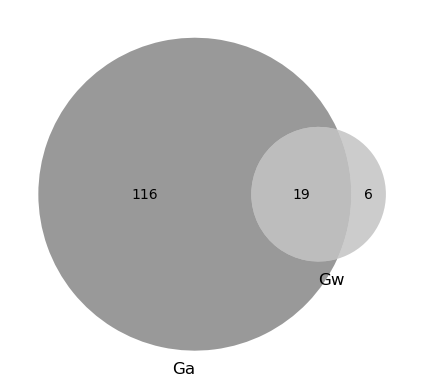

In [49]:
from matplotlib_venn import venn2

set1 = set(list(Ga_retained_Gw_lost.keys())+list(Retained_chr19_genes.keys()))
set2 = set(list(Gw_retained_Ga_lost.keys())+list(Retained_chr19_genes.keys()))

venn2([set1, set2], ('Ga', 'Gw'), ("black", "grey"))

plt.show()

So of the 25 1-1 genes retained in Gw, 19 of them are also retained in Ga. What are the odds of this? 

I can test by randomly drawing 135 (116 + 19) genes for Ga, and doing the same for 25 genes of Gw and seeing how often they overlap by 19 or more. 

In [50]:
import random

## Make a list of "genes"
genes = list(range(888))

## get 1000 samples of 135 genes for Ga
Ga_samples = []
for i in range(1000):
    Ga_samples.append(random.sample(genes, 135))
    
## get 1000 samples of 25 genes for Gw
Gw_samples = []

for i in range(1000):
    Gw_samples.append(random.sample(genes, 25))

In [51]:
## I want to compare pairs of these random pulls (not all against all)

overlaps = []

for i in range(1000):
    overlap = list(set(Ga_samples[i]) & set(Gw_samples[i]))
    overlaps.append(len(overlap))

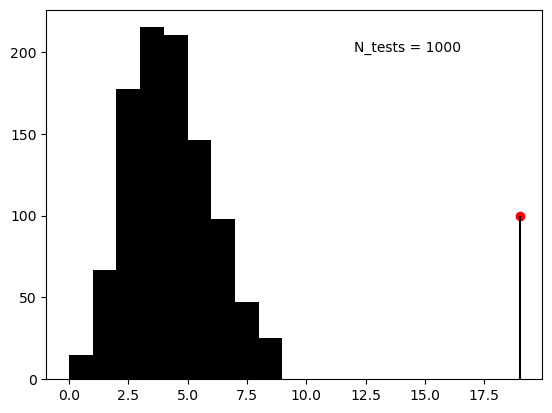

In [53]:
## Lastly, plot the overlaps and compare with the real result. 
plt.hist(overlaps, bins = max(overlaps), color = "black")
plt.vlines(19, 0, 100, color = "black")
plt.scatter(19,100, color = "red")
plt.text(12,200, "N_tests = 1000")
plt.show()

## How many genes have moved onto the Y??

In [54]:
Gw_gene_dict

{'g3687.t1': {'start': 4948, 'end': 27712, 'chrom': 'chr12'},
 'g3688.t1': {'start': 30727, 'end': 60427, 'chrom': 'chr12'},
 'g3689.t2': {'start': 66194, 'end': 91987, 'chrom': 'chr12'},
 'g3690.t1': {'start': 97641, 'end': 120914, 'chrom': 'chr12'},
 'g3691.t1': {'start': 122512, 'end': 127662, 'chrom': 'chr12'},
 'g3692.t1': {'start': 130882, 'end': 146043, 'chrom': 'chr12'},
 'g3693.t1': {'start': 147772, 'end': 148143, 'chrom': 'chr12'},
 'g3694.t1': {'start': 149915, 'end': 163442, 'chrom': 'chr12'},
 'g3695.t1': {'start': 165524, 'end': 242571, 'chrom': 'chr12'},
 'g3696.t1': {'start': 262748, 'end': 283615, 'chrom': 'chr12'},
 'g3697.t1': {'start': 286592, 'end': 290041, 'chrom': 'chr12'},
 'g3698.t1': {'start': 291076, 'end': 297937, 'chrom': 'chr12'},
 'g3699.t1': {'start': 300045, 'end': 308800, 'chrom': 'chr12'},
 'g3700.t1': {'start': 311515, 'end': 312036, 'chrom': 'chr12'},
 'g3701.t1': {'start': 318785, 'end': 327869, 'chrom': 'chr12'},
 'g3702.t1': {'start': 331449, 'e

In [70]:
GwY_Gw_Ga_ortho_info = {}

for OG in N0_dict:
    
    ## get all genes with orthology info for GwY, Gw and Gw
    
    if all(["" not in N0_dict[OG]['GwY'],
            "" not in N0_dict[OG]['Gw'],
            "" not in N0_dict[OG]['Ga']]):
        
        GwY_Gw_Ga_ortho_info[OG] = N0_dict[OG]

        

In [68]:
Ga_gene_dict

{'rna-E2998_mgp13': {'start': 2850, 'end': 3824, 'chrom': 'NC_041244.1'},
 'rna-E2998_mgp12': {'start': 4035, 'end': 5081, 'chrom': 'NC_041244.1'},
 'rna-E2998_mgp11': {'start': 5464, 'end': 7014, 'chrom': 'NC_041244.1'},
 'rna-E2998_mgp10': {'start': 7172, 'end': 7862, 'chrom': 'NC_041244.1'},
 'rna-E2998_mgp09': {'start': 7938, 'end': 8105, 'chrom': 'NC_041244.1'},
 'rna-E2998_mgp08': {'start': 8096, 'end': 8779, 'chrom': 'NC_041244.1'},
 'rna-E2998_mgp07': {'start': 8779, 'end': 9563, 'chrom': 'NC_041244.1'},
 'rna-E2998_mgp06': {'start': 9634, 'end': 9982, 'chrom': 'NC_041244.1'},
 'rna-E2998_mgp05': {'start': 10052, 'end': 10348, 'chrom': 'NC_041244.1'},
 'rna-E2998_mgp04': {'start': 10342, 'end': 11722, 'chrom': 'NC_041244.1'},
 'rna-E2998_mgp03': {'start': 11939, 'end': 13777, 'chrom': 'NC_041244.1'},
 'rna-E2998_mgp02': {'start': 13774, 'end': 14295, 'chrom': 'NC_041244.1'},
 'rna-E2998_mgp01': {'start': 14371, 'end': 15511, 'chrom': 'NC_041244.1'},
 'rna-XM_040171790.1': {'sta

In [71]:
for OG in GwY_Gw_Ga_ortho_info:
    
    keep = True
    
    for Gw_gene in GwY_Gw_Ga_ortho_info[OG]["Gw"]:
        
        if Gw_all_genes_dict[Gw_gene]['chrom'] in ["chr19", "chr12"]:
            
            
            
            keep = False
            
    for Ga_gene in GwY_Gw_Ga_ortho_info[OG]["Ga"]:
        
        if Ga_gene_dict[Ga_gene]['chrom'] in ["NC_053223.1", "NC_053230.1"]:
            
            keep = False
            
    if keep == True:
        
        print(GwY_Gw_Ga_ortho_info[OG])
                
        

{'Aq': [''], 'Ga': ['rna-XM_040173106.1', 'rna-XM_040166447.1', 'rna-XM_040165169.1'], 'GaY': ['rna-XM_040169028.1', 'rna-XM_040169030.1'], 'Gw': ['g7297.t1'], 'GwY': ['g22935.t1'], 'Pp': ['rna-XM_062566212.1']}
{'Aq': ['ApeQuad_10379.1'], 'Ga': ['rna-XM_040183306.1'], 'GaY': ['rna-XM_040167960.1'], 'Gw': ['g20601.t1'], 'GwY': ['g22970.t1'], 'Pp': ['rna-XM_037469420.2']}
{'Aq': ['ApeQuad_21938.1'], 'Ga': ['rna-XM_040203193.1'], 'GaY': [''], 'Gw': ['g17616.t1'], 'GwY': ['g22972.t2'], 'Pp': ['rna-XM_037448034.2']}


# Genetic diversity in Gw Y chromosomes

In [120]:
Gw_pi_path = "/Users/dj20y461/Downloads/Gw_phased_male_chr12_19_100kb.windowed.pi"

chr19x = []
chr19y = []

chr12x = []
chr12y = []

with open(Gw_pi_path) as Gw_pi:
    
    header = next(Gw_pi)
    
    for line in Gw_pi:
        
        CHROM = line.split()[0]
        BIN_START = int(line.split()[1])
        BIN_END = int(line.split()[2])
        BIN_LENGTH = (BIN_END-BIN_START)
        BIN_CENTRE = BIN_START + (BIN_LENGTH/2)
        N_VARS = int(line.split()[3])
        PI = float(line.split()[4])
        
        if CHROM == "chr19":
            chr19x.append(BIN_CENTRE)
            chr19y.append(PI)
        elif CHROM == "chr12":
            chr12x.append(BIN_CENTRE)
            chr12y.append(PI)

### Chr19 Pi

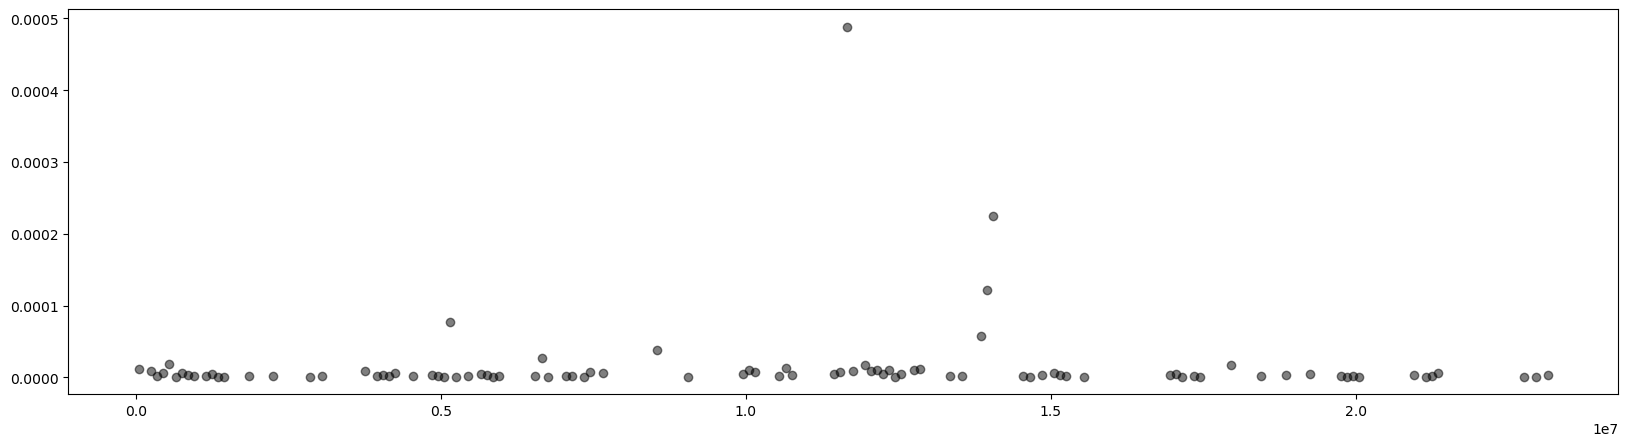

In [121]:
plt.figure(figsize = (20,5))

plt.scatter(chr19x,chr19y, color = "black", alpha = 0.5)
plt.show()

Some very high outliers, see if there is any pattern with these removed - though they should be investigated! 

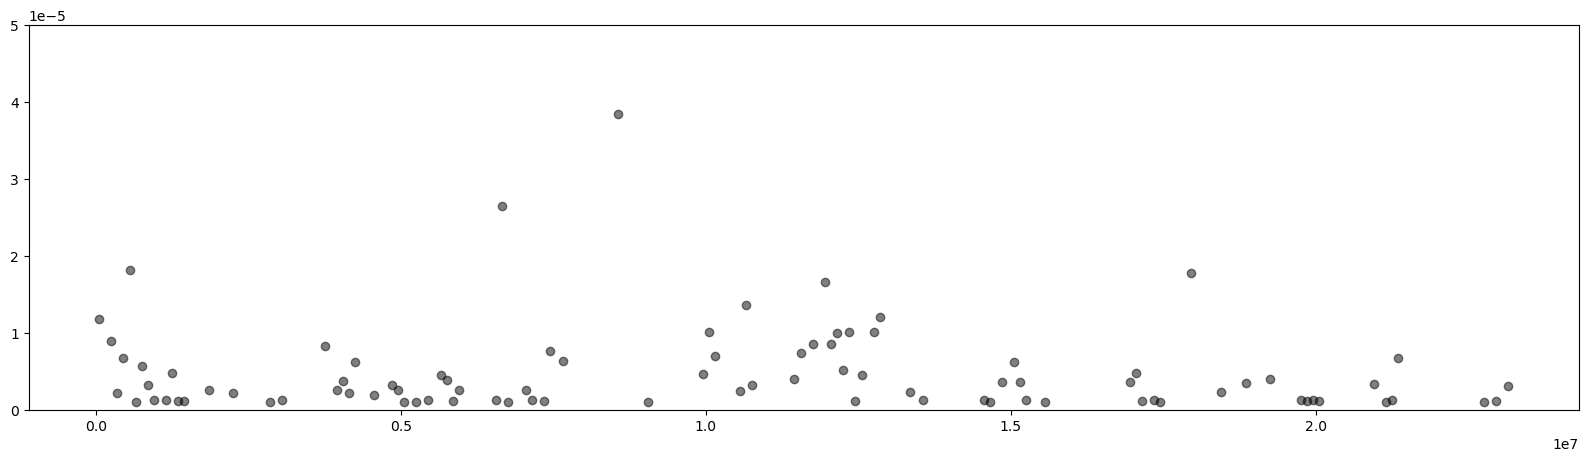

In [122]:
plt.figure(figsize = (20,5))

plt.scatter(chr19x,chr19y, color = "black", alpha = 0.5)
plt.ylim(0,0.00005)
plt.show()

Not much

## Chr12 Pi

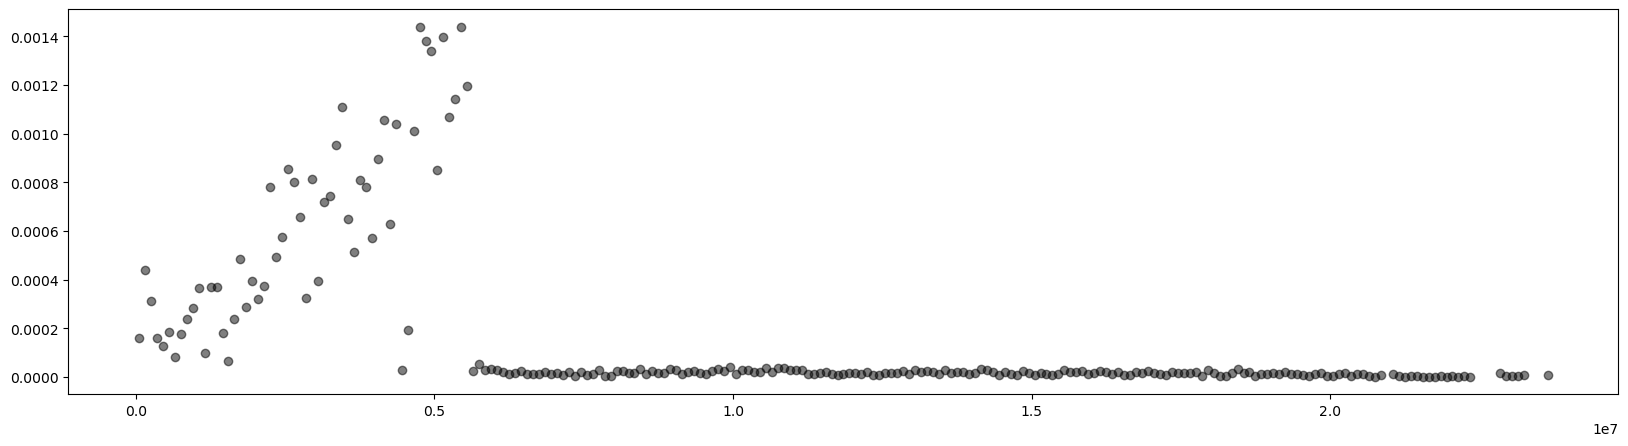

In [124]:
plt.figure(figsize = (20,5))

plt.scatter(chr12x,chr12y, color = "black", alpha = 0.5)
plt.show()

Interesting pattern on the PAR here - but I suppose it can be reconciled with lower recomb at the telomeres perhaps? Though I would have expected the opposite given the telomere-centric recombination. 

But lets see if there is anything going on in the SL region after we remove the PAR. 

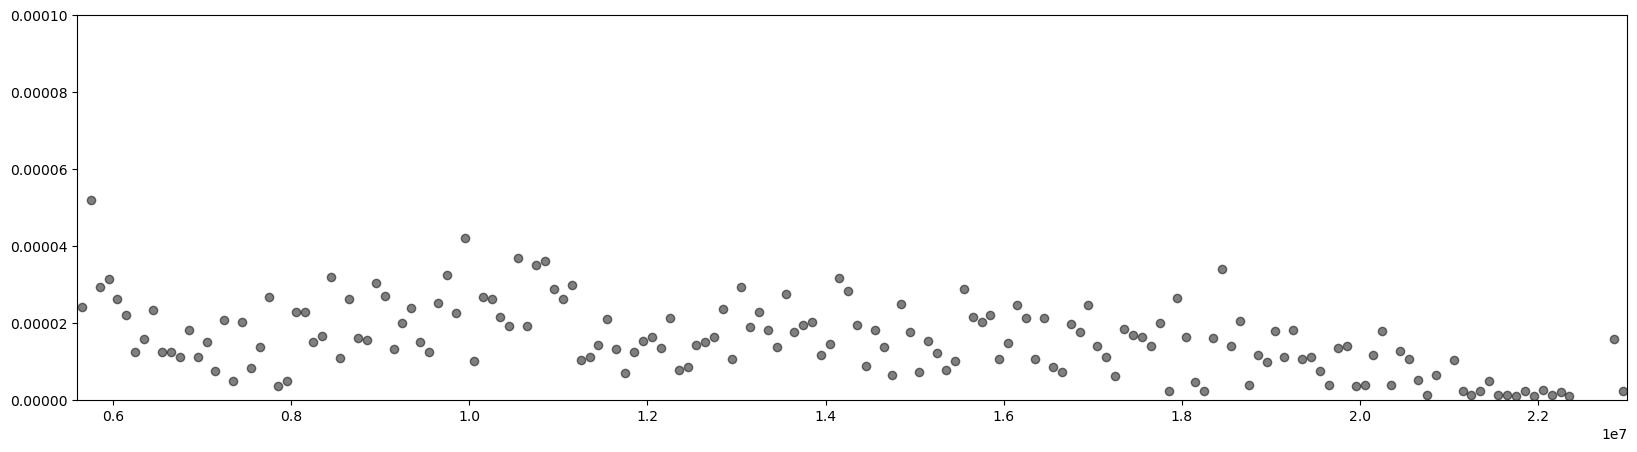

In [129]:
plt.figure(figsize = (20,5))

plt.scatter(chr12x,chr12y, color = "black", alpha = 0.5)
plt.xlim(5600000,23000000)
plt.ylim(0,0.0001)
plt.show()